# Preparation

* ใช้ DataFrame จาก pandas จัดการข้อมูล
```
import pandas as pd
```
* ใช้ KMeans จาก sklearn.cluster เพื่อทำ Clustering
```
from sklearn.cluster import KMeans
```
* (optional) ใช้ matplotlib.pyplot ในการวาดกราฟ
```
import matplotlib.pyplot as plt
```
* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
from yellowbrick.cluster import KElbowVisualizer
```

In [37]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer

# **Lab-1** Customer Segmentation

## สร้าง DataFrame เพื่อจัดการชุดข้อมูล

1.   สร้างชุดข้อมูลจากตัวอย่างในสไลด์
```
{
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}
```

In [38]:
{
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}

{'age': [42, 18, 23, 49, 37, 51, 40, 20], 'eng': [7, 3, 2, 1, 7, 1, 6, 4]}

2.   สร้าง DataFrame จากชุดข้อมูล
```
pd.DataFrame()
```

In [39]:
df = pd.DataFrame({'age': [42, 18, 23, 49, 37, 51, 40, 20], 'eng': [7, 3, 2, 1, 7, 1, 6, 4]})
df

,age,eng
0,42,7
1,18,3
2,23,2
3,49,1
4,37,7
5,51,1
6,40,6
7,20,4


## สร้างโมเดลของ k-means
```
KMeans(n_clusters=?)
```

In [40]:
kmeans = KMeans(n_clusters=3, random_state=42)

## ให้ model เรียนรู้จากชุดข้อมูลใน DataFrame
```
fit()
```

In [41]:
kmeans.fit(df)

KMeans(n_clusters=3, random_state=42)

## ดูผลการทำ Clustering

* Centroids
```
cluster_centers_
```

In [42]:
kmeans.cluster_centers_

array([[20.33333333,  3.        ],
       [39.66666667,  6.66666667],
       [50.        ,  1.        ]])

* Labels
```
labels_
```

In [43]:
kmeans.labels_

array([1, 0, 0, 2, 1, 2, 1, 0], dtype=int32)

## (optional) วาดกราฟ
```
plt.scatter()
```

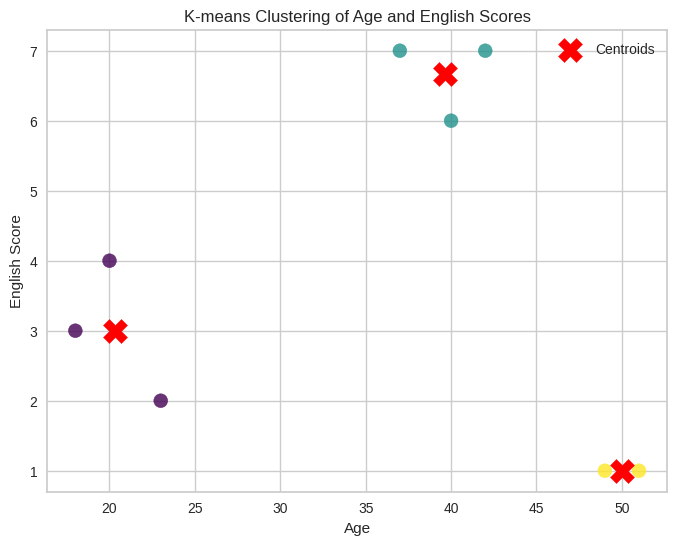

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['eng'], c=kmeans.labels_, cmap='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('K-means Clustering of Age and English Scores')
plt.xlabel('Age')
plt.ylabel('English Score')
plt.legend()
plt.grid(True)
plt.show()

## Add the cluster labels to the original data

In [45]:
df['cluster'] = kmeans.labels_
df

,age,eng,cluster
0,42,7,1
1,18,3,0
2,23,2,0
3,49,1,2
4,37,7,1
5,51,1,2
6,40,6,1
7,20,4,0


## Within Cluster Sum Of Square
```
inertia_
```

In [46]:
kmeans.inertia_

30.000000000000004

# **Lab-2** - Grains Clustering

ใช้ข้อมูลของธัญญพืชที่ให้มานี้ แสดงวิธีการทำ Clustering โดยหาจำนวนกลุ่มที่เหมาะสมที่สุด พร้อมทั้งอธิบายลักษณะของแต่ละกลุ่มที่ได้
```
{
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
}
```

In [47]:
df2 = pd.DataFrame(
    {
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
    }
)
df2

,sugar,cal,protein,fat,sodium
0,6,70,4,1,130
1,8,120,3,5,15
2,5,70,4,1,260
3,0,50,4,0,140
4,8,110,2,2,200
5,10,110,2,2,180
6,14,110,2,0,125
7,8,130,3,2,210
8,6,90,2,1,200
9,5,90,3,0,210


## Determining the number of clusters to be formed
* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
from yellowbrick.cluster import KElbowVisualizer
```
* สร้างโมเดลของ KElbowVisualizer
```
KElbowVisualizer(KMeans(), k=(2, ?))
```
* ให้ model เรียนรู้และแสดงผลกราฟ Elbow
```
fit()
show()
```

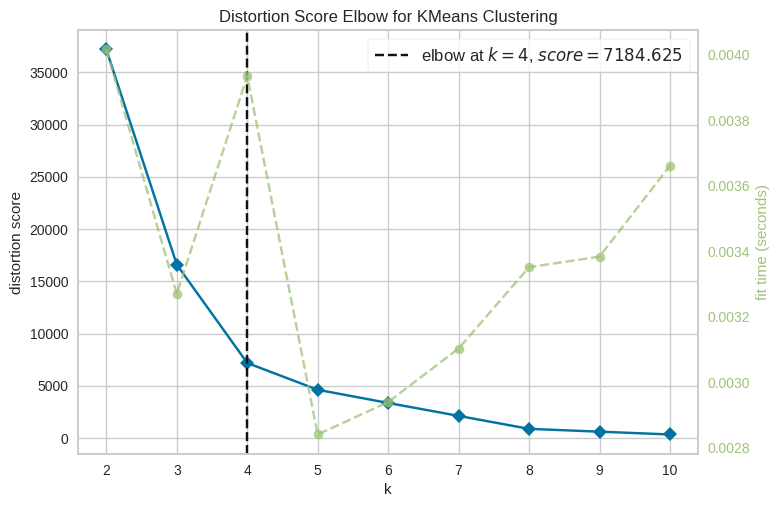

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [48]:
from yellowbrick.cluster import KElbowVisualizer
kelbow = KElbowVisualizer(KMeans(df2), k=(2, 11))
kelbow.fit(df2)
kelbow.show()

## Workshop: Implementing K-Means Clustering
* เลือกใช้จำนวนกลุ่ม k ที่เหมาะสม จัดกลุ่มธัญพืช และอธิบายผลลัพธ์ที่ได้

In [49]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df2)

KMeans(n_clusters=4, random_state=42)

In [50]:
df2['cluster'] = kmeans.labels_
df2

,sugar,cal,protein,fat,sodium,cluster
0,6,70,4,1,130,3
1,8,120,3,5,15,2
2,5,70,4,1,260,1
3,0,50,4,0,140,3
4,8,110,2,2,200,0
5,10,110,2,2,180,0
6,14,110,2,0,125,3
7,8,130,3,2,210,0
8,6,90,2,1,200,0
9,5,90,3,0,210,0


In [51]:
kmeans.cluster_centers_

array([[  8.875, 110.   ,   1.875,   1.625, 201.25 ],
       [  3.   ,  90.   ,   5.   ,   1.5  , 275.   ],
       [  8.   , 120.   ,   3.   ,   5.   ,  15.   ],
       [  6.75 ,  85.   ,   3.25 ,   0.75 , 133.75 ]])

In [52]:
df2.groupby('cluster').mean()

,sugar,cal,protein,fat,sodium
cluster,,,,,
0,8.875,110.0,1.875,1.625,201.25
1,3.000,90.0,5.000,1.500,275.00
2,8.000,120.0,3.000,5.000,15.00
3,6.750,85.0,3.250,0.750,133.75


In [53]:
df2.groupby('cluster').count()

,sugar,cal,protein,fat,sodium
cluster,,,,,
0,8,8,8,8,8
1,2,2,2,2,2
2,1,1,1,1,1
3,4,4,4,4,4


สรุปผลการทำ Clustering

- ใช้คำสั่ง groupby('cluster').count() เพื่อนับจำนวนข้อมูลในแต่ละคลัสเตอร์
- ผลลัพธ์แบ่งข้อมูลออกเป็น 4 กลุ่ม (cluster 0-3)

จำนวนสมาชิกในแต่ละกลุ่ม
- Cluster 0 : 8 รายการ (กลุ่มใหญ่ที่สุด)
- Cluster 3 : 4 รายการ
- Cluster 1 : 2 รายการ
- Cluster 2 : 1 รายการ (กลุ่มเล็กที่สุด อาจเป็น outlier)
- รวมทั้งหมด : 8+4+2+1 = 15 รายการ

ข้อสังเกตเรื่อง missing values
- ทุกคอลัมน์ (sugar, cal, protein, fat, sodium) มีค่านับเท่ากันในทุกแถว
- แสดงว่าข้อมูลชุดนี้ไม่มีค่า missing (NaN) เลย

สรุป
- การแบ่งกลุ่มมีขนาดไม่เท่ากัน
- Cluster 2 ที่มีแค่ 1 รายการ อาจต้องตรวจสอบเพิ่มเติมว่าเป็น outlier หรือกลุ่มที่มีลักษณะเฉพาะจริง ๆ

In [54]:
df2.drop('cluster', axis=1)

,sugar,cal,protein,fat,sodium
0,6,70,4,1,130
1,8,120,3,5,15
2,5,70,4,1,260
3,0,50,4,0,140
4,8,110,2,2,200
5,10,110,2,2,180
6,14,110,2,0,125
7,8,130,3,2,210
8,6,90,2,1,200
9,5,90,3,0,210


In [55]:
kmeans.labels_

array([3, 2, 1, 3, 0, 0, 3, 0, 0, 0, 0, 1, 0, 3, 0], dtype=int32)

## สรุปคะแนน Performance เบื้องต้น

### Silhouette Score
```
from sklearn.metrics import silhouette_score
```
* คำนวณค่า Silhouette Score ของโมเดล
```
silhouette_score(X, labels)

In [56]:
from sklearn.metrics import silhouette_score
silhouette_score(df2, kmeans.labels_)

0.4974349534533541

### Davies-Bouldin Index (DBI)
```
from sklearn.metrics import davies_bouldin_score
```
* คำนวณค่า Davies-Bouldin Index (DBI) ของโมเดล
```
davies_bouldin_score(X, labels)
```

In [57]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(df2, kmeans.labels_)

0.5001255653040731

### Calinski-Harabasz Index (CHI)
```
from sklearn.metrics import calinski_harabasz_score
```
* คำนวณค่า Calinski-Harabasz Index (CHI) ของโมเดล
```
calinski_harabasz_score(X, labels)
```

In [58]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(df2, kmeans.labels_)

30.531756277390187

## Comparing Clustering Performance เพื่อเลือกค่า k ที่เหมาะสม
* สร้าง list ของ [score, k]
* ทดลอง k = 2, 3, 4, 5, 6, ...
* สร้างโมเดล K-Means สำหรับค่า k นั้น ในแต่ละรอบ


In [59]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

results = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df2)

    sh = silhouette_score(df2, labels)
    db = davies_bouldin_score(df2, labels)
    ch = calinski_harabasz_score(df2, labels)

    results.append({
        'k': k,
        'silhouette': sh,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

# Display as a DataFrame for easy comparison
results_df = pd.DataFrame(results)
results_df

,k,silhouette,davies_bouldin,calinski_harabasz
0,2,0.380046,0.673185,5.888344
1,3,0.417355,0.498940,13.105267
2,4,0.497435,0.500126,30.531756
3,5,0.517565,0.401391,33.763694
4,6,0.452694,0.286686,34.107494
5,7,0.232106,0.641700,33.838988


In [60]:
# Downgrade numpy to be compatible with scikit-learn-extra
!pip install "numpy<2" scikit-learn-extra

In [61]:
import pandas as pd
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

results_manhattan = []

for k in range(2, 8):
    # ใช้ KMedoids และกำหนด metric='manhattan'
    kmedoids = KMedoids(n_clusters=k, metric='manhattan', random_state=42)
    labels = kmedoids.fit_predict(df2)

    # คำนวณ Silhouette Score โดยใช้ metric='manhattan'
    sh = silhouette_score(df2, labels, metric='manhattan')
    db = davies_bouldin_score(df2, labels)
    ch = calinski_harabasz_score(df2, labels)

    results_manhattan.append({
        'k': k,
        'silhouette_man': sh,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

# แสดงผลลัพธ์ในรูปแบบ DataFrame
results_man_df = pd.DataFrame(results_manhattan)
display(results_man_df)

,k,silhouette_man,davies_bouldin,calinski_harabasz
0,2,0.467684,0.745584,17.166437
1,3,0.101343,0.728934,9.730831
2,4,0.148409,1.108033,6.888652
3,5,0.208033,1.407597,5.176882
4,6,0.272889,1.372978,5.615482
5,7,0.144414,0.985410,4.759650


### Silhouette Score


### Davies-Bouldin Index (DBI)


### Calinski-Harabasz Index (CHI)


## Refining Clustering Analysis:

* Define the number of clusters